Student Performance Analysis
Author: Priyanshi

Project Goal: Determine which academic, behavioral, and demographic factors are most strongly associated with student exam performance.

In [1]:
import pandas as pd

In [2]:
import os
os.listdir()

['.ipynb_checkpoints', 'analysis2.ipynb', 'StudentPerformanceFactors.csv']

In [2]:
df = pd.read_csv("StudentPerformanceFactors.csv")

In [4]:
df.shape

(6607, 20)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6529 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence              6607 non-null   obje

In [6]:
df.isnull().sum()

Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality               78
School_Type                    0
Peer_Influence                 0
Physical_Activity              0
Learning_Disabilities          0
Parental_Education_Level      90
Distance_from_Home            67
Gender                         0
Exam_Score                     0
dtype: int64

In [7]:
df['Teacher_Quality'].unique()

array(['Medium', 'High', 'Low', nan], dtype=object)

In [8]:
df.columns

Index(['Hours_Studied', 'Attendance', 'Parental_Involvement',
       'Access_to_Resources', 'Extracurricular_Activities', 'Sleep_Hours',
       'Previous_Scores', 'Motivation_Level', 'Internet_Access',
       'Tutoring_Sessions', 'Family_Income', 'Teacher_Quality', 'School_Type',
       'Peer_Influence', 'Physical_Activity', 'Learning_Disabilities',
       'Parental_Education_Level', 'Distance_from_Home', 'Gender',
       'Exam_Score'],
      dtype='object')

In [9]:
df['Exam_Score'].describe()

count    6607.000000
mean       67.235659
std         3.890456
min        55.000000
25%        65.000000
50%        67.000000
75%        69.000000
max       101.000000
Name: Exam_Score, dtype: float64

One observation exceeds the conventional upper limit of 100 and should be investigated during outlier analysis.

<Axes: >

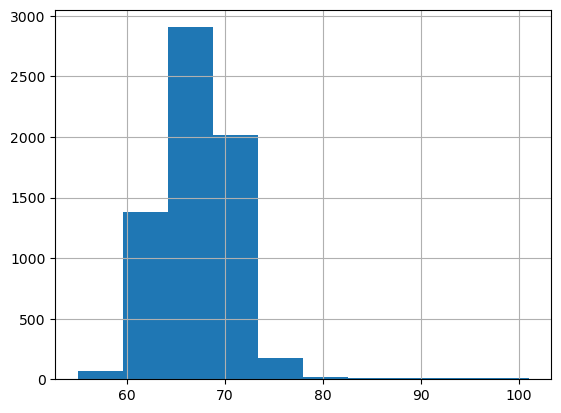

In [4]:
df['Exam_Score'].hist()

Exam scores are concentrated around the mean of 67, with relatively little variability and no evidence of extreme skewness. Most students scored between approximately 65 and 70.

In [11]:
df['Previous_Scores'].describe()

count    6607.000000
mean       75.070531
std        14.399784
min        50.000000
25%        63.000000
50%        75.000000
75%        88.000000
max       100.000000
Name: Previous_Scores, dtype: float64

In [12]:
df[['Previous_Scores','Exam_Score']].corr()

,Previous_Scores,Exam_Score
Previous_Scores,1.000000,0.175079
Exam_Score,0.175079,1.000000


There is a positive linear association between Previous_Scores and Exam_Score and The relationship appears weak to modest.

In [13]:
df['Hours_Studied'].describe()

count    6607.000000
mean       19.975329
std         5.990594
min         1.000000
25%        16.000000
50%        20.000000
75%        24.000000
max        44.000000
Name: Hours_Studied, dtype: float64

In [14]:
df[['Hours_Studied','Exam_Score']].corr()

,Hours_Studied,Exam_Score
Hours_Studied,1.000000,0.445455
Exam_Score,0.445455,1.000000


A moderate positive linear relationship between Hours_Studied and Exam_Score.In other words:Students who study more tend to score higher

In [15]:
df['Attendance'].describe()

count    6607.000000
mean       79.977448
std        11.547475
min        60.000000
25%        70.000000
50%        80.000000
75%        90.000000
max       100.000000
Name: Attendance, dtype: float64

In [16]:
df[['Attendance','Exam_Score']].corr()

,Attendance,Exam_Score
Attendance,1.000000,0.581072
Exam_Score,0.581072,1.000000


This is a moderately strong positive linear relationship.
Students with higher attendance tend to score higher.

In [17]:
df['Sleep_Hours'].describe()

count    6607.00000
mean        7.02906
std         1.46812
min         4.00000
25%         6.00000
50%         7.00000
75%         8.00000
max        10.00000
Name: Sleep_Hours, dtype: float64

In [18]:
df[['Sleep_Hours','Exam_Score']].corr()

,Sleep_Hours,Exam_Score
Sleep_Hours,1.000000,-0.017022
Exam_Score,-0.017022,1.000000


Essentially zero.
There is no evidence of a meaningful linear relationship between sleep hours and exam scores.

In [19]:
df['Teacher_Quality'].value_counts()

Teacher_Quality
Medium    3925
High      1947
Low        657
Name: count, dtype: int64

In [20]:
df.groupby('Teacher_Quality')['Exam_Score'].mean()

Teacher_Quality
High      67.676939
Low       66.753425
Medium    67.109299
Name: Exam_Score, dtype: float64

Students reporting high teacher quality tend to have slightly higher average exam scores.

In [21]:
df['Motivation_Level'].value_counts()

Motivation_Level
Medium    3351
Low       1937
High      1319
Name: count, dtype: int64

In [22]:
df.groupby('Motivation_Level')['Exam_Score'].mean()

Motivation_Level
High      67.704321
Low       66.752194
Medium    67.330648
Name: Exam_Score, dtype: float64

High motivation have the highest average scores.
Low motivation have the lowest average scores.
Students with higher motivation levels tend to achieve slightly higher average exam scores, although the magnitude of the difference is modest.

In [23]:
df['Tutoring_Sessions'].describe()

count    6607.000000
mean        1.493719
std         1.230570
min         0.000000
25%         1.000000
50%         1.000000
75%         2.000000
max         8.000000
Name: Tutoring_Sessions, dtype: float64

In [24]:
df[['Tutoring_Sessions','Exam_Score']].corr()

,Tutoring_Sessions,Exam_Score
Tutoring_Sessions,1.000000,0.156525
Exam_Score,0.156525,1.000000


In [25]:
df['Physical_Activity'].describe()

count    6607.000000
mean        2.967610
std         1.031231
min         0.000000
25%         2.000000
50%         3.000000
75%         4.000000
max         6.000000
Name: Physical_Activity, dtype: float64

In [26]:
df[['Physical_Activity','Exam_Score']].corr()

,Physical_Activity,Exam_Score
Physical_Activity,1.000000,0.027824
Exam_Score,0.027824,1.000000


This correlation is extremely close to zero.
There is essentially no meaningful linear relationship between Physical_Activity and Exam_Score in this dataset.
In practical terms:
More exercise does not appear to be associated with substantially higher scores.
Less exercise does not appear to be associated with lower scores.

In [27]:
df['Family_Income'].value_counts()

Family_Income
Low       2672
Medium    2666
High      1269
Name: count, dtype: int64

In [28]:
df.groupby('Family_Income')['Exam_Score'].mean()

Family_Income
High      67.842396
Low       66.848428
Medium    67.334959
Name: Exam_Score, dtype: float64

Students from higher-income families tend to have slightly higher average exam scores.

In [29]:
df['Access_to_Resources'].value_counts()

Access_to_Resources
Medium    3319
High      1975
Low       1313
Name: count, dtype: int64

In [30]:
df.groupby('Access_to_Resources')['Exam_Score'].mean()

Access_to_Resources
High      68.092152
Low       66.203351
Medium    67.134378
Name: Exam_Score, dtype: float64

In [31]:
df['Parental_Involvement'].value_counts()

Parental_Involvement
Medium    3362
High      1908
Low       1337
Name: count, dtype: int64

In [32]:
df.groupby('Parental_Involvement')['Exam_Score'].mean()

Parental_Involvement
High      68.092767
Low       66.358265
Medium    67.098156
Name: Exam_Score, dtype: float64

In [33]:
df['Peer_Influence'].value_counts()

Peer_Influence
Positive    2638
Neutral     2592
Negative    1377
Name: count, dtype: int64

In [34]:
df.groupby('Peer_Influence')['Exam_Score'].mean()

Peer_Influence
Negative    66.564270
Neutral     67.197917
Positive    67.623199
Name: Exam_Score, dtype: float64

In [35]:
df['Internet_Access'].value_counts()

Internet_Access
Yes    6108
No      499
Name: count, dtype: int64

In [36]:
df.groupby('Internet_Access')['Exam_Score'].mean()

Internet_Access
No     66.535070
Yes    67.292895
Name: Exam_Score, dtype: float64

In [37]:
df['Extracurricular_Activities'].value_counts()

Extracurricular_Activities
Yes    3938
No     2669
Name: count, dtype: int64

In [38]:
df.groupby('Extracurricular_Activities')['Exam_Score'].mean()

Extracurricular_Activities
No     66.931435
Yes    67.441849
Name: Exam_Score, dtype: float64

Students who participate in extracurricular activities tend to achieve slightly higher exam scores.

In [39]:
df['School_Type'].value_counts()

School_Type
Public     4598
Private    2009
Name: count, dtype: int64

In [40]:
df.groupby('School_Type')['Exam_Score'].mean()

School_Type
Private    67.287705
Public     67.212919
Name: Exam_Score, dtype: float64

Educational support and student behaviors matter much more than whether the school is public or private.

In [41]:
df['Gender'].value_counts()

Gender
Male      3814
Female    2793
Name: count, dtype: int64

In [42]:
df.groupby('Gender')['Exam_Score'].mean()

Gender
Female    67.244898
Male      67.228894
Name: Exam_Score, dtype: float64

In [43]:
df['Learning_Disabilities'].value_counts()

Learning_Disabilities
No     5912
Yes     695
Name: count, dtype: int64

In [44]:
df.groupby('Learning_Disabilities')['Exam_Score'].mean()

Learning_Disabilities
No     67.349120
Yes    66.270504
Name: Exam_Score, dtype: float64

In [45]:
df['Parental_Education_Level'].value_counts()

Parental_Education_Level
High School     3223
College         1989
Postgraduate    1305
Name: count, dtype: int64

In [46]:
df.groupby('Parental_Education_Level')['Exam_Score'].mean()

Parental_Education_Level
College         67.315737
High School     66.893577
Postgraduate    67.970881
Name: Exam_Score, dtype: float64

In [47]:
df['Distance_from_Home'].value_counts()

Distance_from_Home
Near        3884
Moderate    1998
Far          658
Name: count, dtype: int64

In [48]:
df.groupby('Distance_from_Home')['Exam_Score'].mean()

Distance_from_Home
Far         66.457447
Moderate    66.981481
Near        67.512101
Name: Exam_Score, dtype: float64

In [49]:
df.isnull().sum()

Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality               78
School_Type                    0
Peer_Influence                 0
Physical_Activity              0
Learning_Disabilities          0
Parental_Education_Level      90
Distance_from_Home            67
Gender                         0
Exam_Score                     0
dtype: int64

In [50]:
df[df.isnull().any(axis=1)].shape

(229, 20)

In [51]:
df[df.isnull().any(axis=1)].head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
33,14,60,High,Medium,No,5,50,Medium,Yes,2,Medium,Medium,Public,Neutral,3,No,College,NaN,Female,61
127,17,97,Medium,Medium,No,8,89,Medium,Yes,1,Low,NaN,Public,Neutral,4,No,High School,Far,Male,69
240,15,87,Low,Medium,No,4,54,Medium,Yes,1,Medium,Medium,Public,Neutral,6,No,NaN,Moderate,Male,65
275,23,82,Low,Medium,Yes,8,94,Medium,Yes,1,Medium,Medium,Public,Negative,2,Yes,High School,NaN,Male,66
316,24,90,Low,Low,No,7,83,Medium,Yes,0,Low,Medium,Private,Positive,3,No,College,NaN,Male,68


In [52]:
df[df.isnull().any(axis=1)]['Exam_Score'].describe()

count    229.000000
mean      66.777293
std        3.129964
min       58.000000
25%       65.000000
50%       67.000000
75%       69.000000
max       74.000000
Name: Exam_Score, dtype: float64

In [53]:
df['Teacher_Quality'].value_counts()

Teacher_Quality
Medium    3925
High      1947
Low        657
Name: count, dtype: int64

In [54]:
df['Parental_Education_Level'].value_counts()

Parental_Education_Level
High School     3223
College         1989
Postgraduate    1305
Name: count, dtype: int64

In [55]:
df['Distance_from_Home'].value_counts()

Distance_from_Home
Near        3884
Moderate    1998
Far          658
Name: count, dtype: int64

In [56]:
df['Teacher_Quality'] = df['Teacher_Quality'].fillna('Unknown')

df['Parental_Education_Level'] = df['Parental_Education_Level'].fillna('Unknown')

df['Distance_from_Home'] = df['Distance_from_Home'].fillna('Unknown')

In [57]:
df.isnull().sum()

Hours_Studied                 0
Attendance                    0
Parental_Involvement          0
Access_to_Resources           0
Extracurricular_Activities    0
Sleep_Hours                   0
Previous_Scores               0
Motivation_Level              0
Internet_Access               0
Tutoring_Sessions             0
Family_Income                 0
Teacher_Quality               0
School_Type                   0
Peer_Influence                0
Physical_Activity             0
Learning_Disabilities         0
Parental_Education_Level      0
Distance_from_Home            0
Gender                        0
Exam_Score                    0
dtype: int64

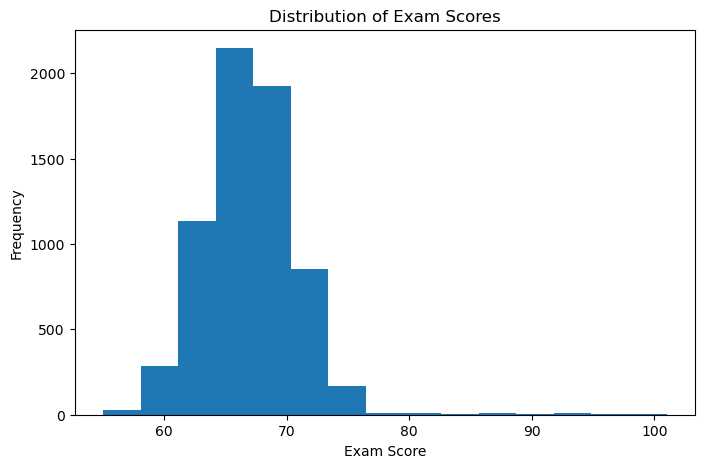

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df['Exam_Score'], bins=15)

plt.xlabel('Exam Score')
plt.ylabel('Frequency')
plt.title('Distribution of Exam Scores')

plt.show()

approximately normal with slight positive (right) skew.

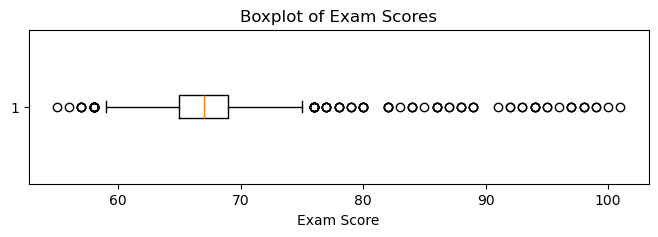

In [59]:
plt.figure(figsize=(8,2))

plt.boxplot(df['Exam_Score'], vert=False)

plt.xlabel('Exam Score')
plt.title('Boxplot of Exam Scores')

plt.show()

The distribution has several upper-tail outliers.Thus, outliers exist on both sides, although there are many more on the high side.

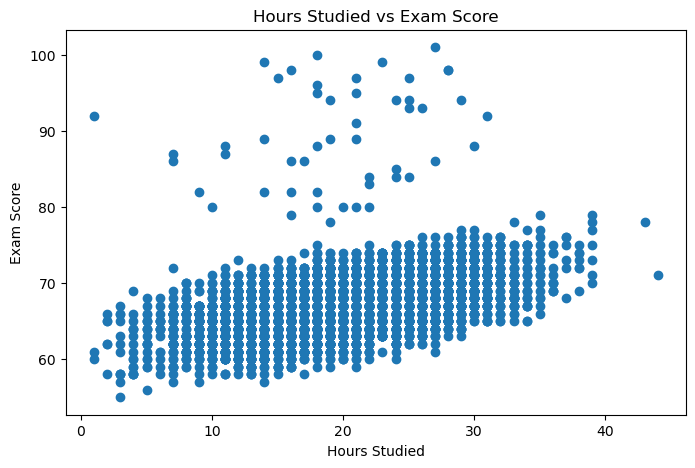

In [60]:
plt.figure(figsize=(8,5))

plt.scatter(df['Hours_Studied'], df['Exam_Score'])

plt.xlabel('Hours Studied')
plt.ylabel('Exam Score')
plt.title('Hours Studied vs Exam Score')

plt.show()

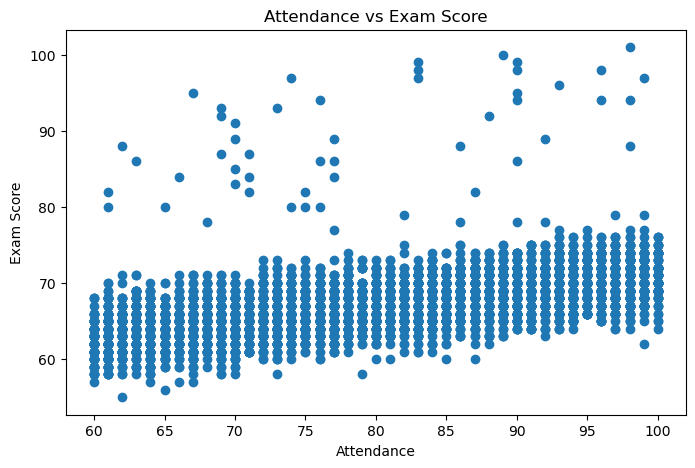

In [61]:
plt.figure(figsize=(8,5))

plt.scatter(df['Attendance'], df['Exam_Score'])

plt.xlabel('Attendance')
plt.ylabel('Exam Score')
plt.title('Attendance vs Exam Score')

plt.show()

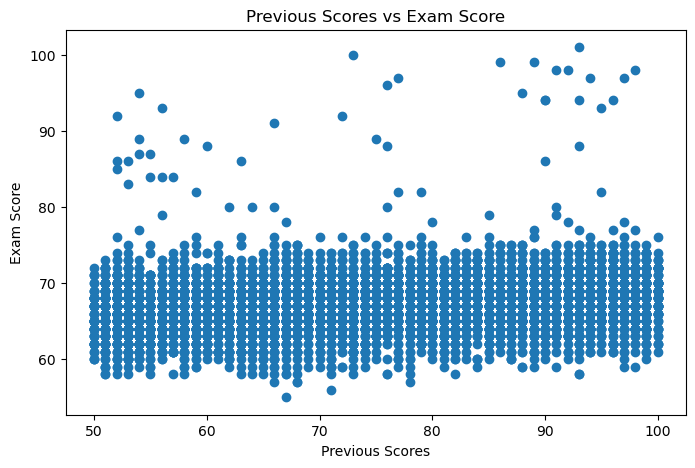

In [62]:
plt.figure(figsize=(8,5))

plt.scatter(df['Previous_Scores'], df['Exam_Score'])

plt.xlabel('Previous Scores')
plt.ylabel('Exam Score')
plt.title('Previous Scores vs Exam Score')

plt.show()

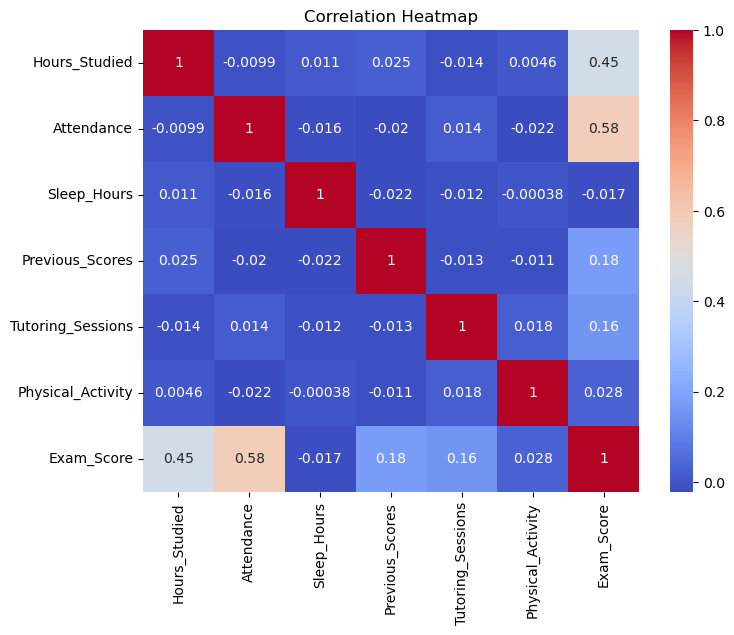

In [63]:
import seaborn as sns

plt.figure(figsize=(8,6))

corr_matrix = df.select_dtypes(include=['int64']).corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')

plt.title('Correlation Heatmap')

plt.show()

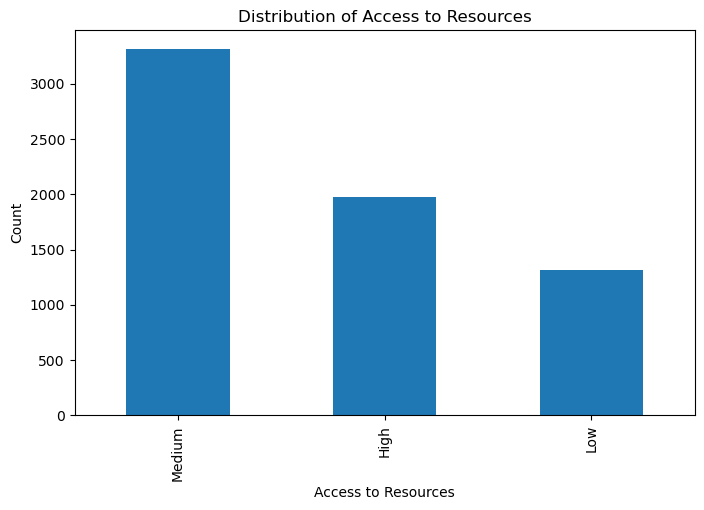

In [64]:
plt.figure(figsize=(8,5))

df['Access_to_Resources'].value_counts().plot(kind='bar')

plt.xlabel('Access to Resources')
plt.ylabel('Count')
plt.title('Distribution of Access to Resources')

plt.show()

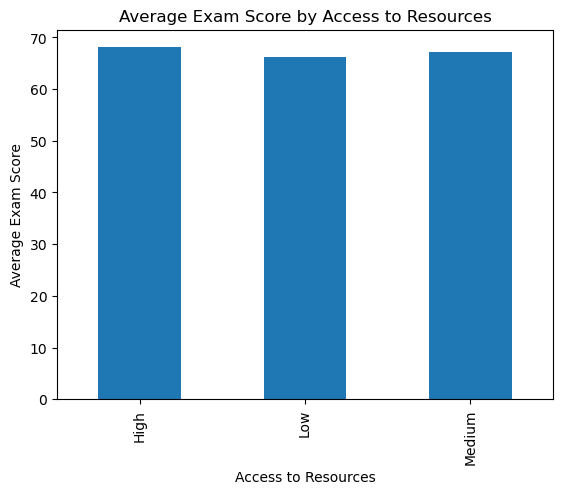

In [65]:
df.groupby('Access_to_Resources')['Exam_Score'].mean().plot(kind='bar')

plt.xlabel('Access to Resources')
plt.ylabel('Average Exam Score')
plt.title('Average Exam Score by Access to Resources')

plt.show()

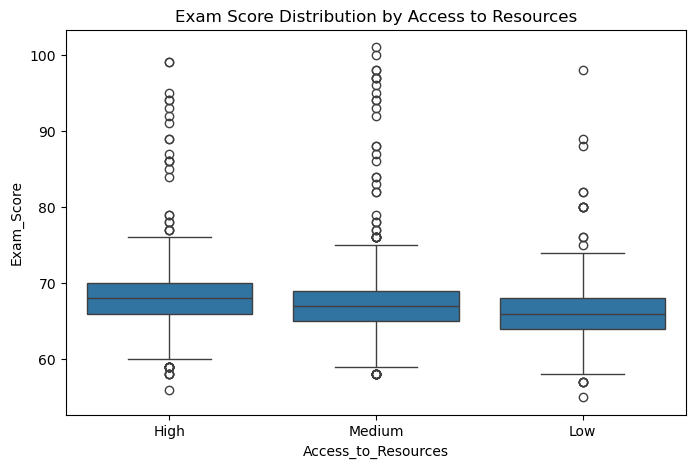

In [66]:
import seaborn as sns

plt.figure(figsize=(8,5))

sns.boxplot(
    x='Access_to_Resources',
    y='Exam_Score',
    data=df
)

plt.title('Exam Score Distribution by Access to Resources')

plt.show()

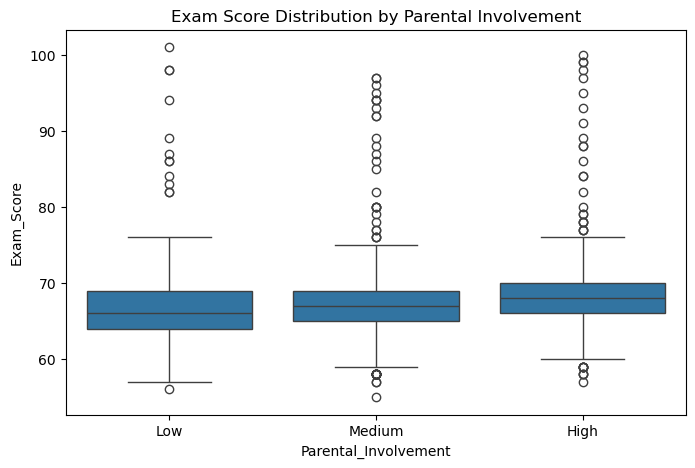

In [67]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Parental_Involvement',
    y='Exam_Score',
    data=df
)

plt.title('Exam Score Distribution by Parental Involvement')

plt.show()

The boxes are very similar in size.

This suggests:

Higher parental involvement raises the overall level of performance but does not dramatically change the spread of scores.

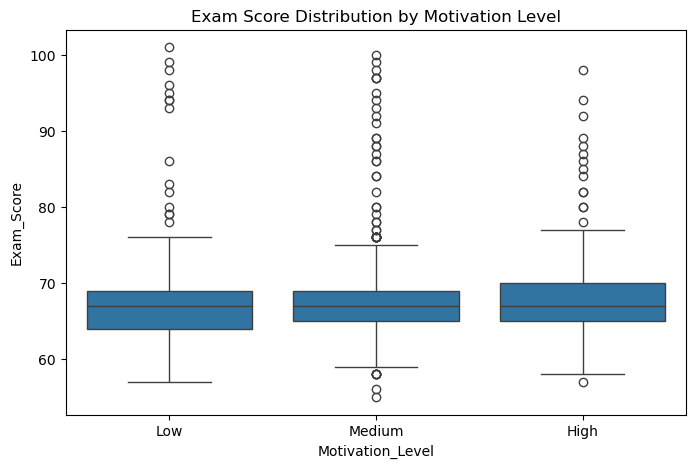

In [68]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Motivation_Level',
    y='Exam_Score',
    data=df
)

plt.title('Exam Score Distribution by Motivation Level')

plt.show()

In [16]:
from scipy.stats import f_oneway

high = df[df['Access_to_Resources']=='High']['Exam_Score']
medium = df[df['Access_to_Resources']=='Medium']['Exam_Score']
low = df[df['Access_to_Resources']=='Low']['Exam_Score']

f_stat, p_value = f_oneway(high, medium, low)

print("F-statistic:", f_stat)
print("P-value:", p_value)

F-statistic: 98.00440911486005
P-value: 1.1392993838170287e-42


There is strong statistical evidence that:

Mean exam scores differ significantly across the three levels of Access to Resources.

Access to Resources has a statistically significant association with Exam Score.

In [17]:
high = df[df['Parental_Involvement']=='High']['Exam_Score']
medium = df[df['Parental_Involvement']=='Medium']['Exam_Score']
low = df[df['Parental_Involvement']=='Low']['Exam_Score']

f_stat, p_value = f_oneway(high, medium, low)

print("F-statistic:", f_stat)
print("P-value:", p_value)

F-statistic: 84.48765484606238
P-value: 5.875479153325444e-37


The probability of observing differences this large purely by chance is extraordinarily small.
    There is strong statistical evidence that parental involvement is associated with differences in exam scores.

In [71]:
high = df[df['Motivation_Level']=='High']['Exam_Score']
medium = df[df['Motivation_Level']=='Medium']['Exam_Score']
low = df[df['Motivation_Level']=='Low']['Exam_Score']

f_stat, p_value = f_oneway(high, medium, low)

print("F-statistic:", f_stat)
print("P-value:", p_value)

F-statistic: 25.71676995037609
P-value: 7.492319380241663e-12


In [72]:
from scipy.stats import pearsonr

corr, p_value = pearsonr(
    df['Hours_Studied'],
    df['Exam_Score']
)

print("Correlation:", corr)
print("P-value:", p_value)

Correlation: 0.4454549540752819
P-value: 1.28635e-319


The correlation coefficient
r ≈ 0.445
indicates a moderate positive linear relationship.
Therefore:
Students who study more hours tend to obtain higher exam scores, and this relationship is statistically significant.

In [73]:
from sklearn.linear_model import LinearRegression

X = df[['Hours_Studied']]
y = df['Exam_Score']

model = LinearRegression()

model.fit(X, y)

print("Intercept:", model.intercept_)
print("Slope:", model.coef_[0])
print("R² Score:", model.score(X, y))

Intercept: 61.45698360950407
Slope: 0.28929062860958055
R² Score: 0.19843011611021155


Slope = 0.289 This means:For every additional hour studied, the predicted exam score increases by approximately 0.289 points.Hours Studied alone explains about 19.8% of the variation in Exam Scores.

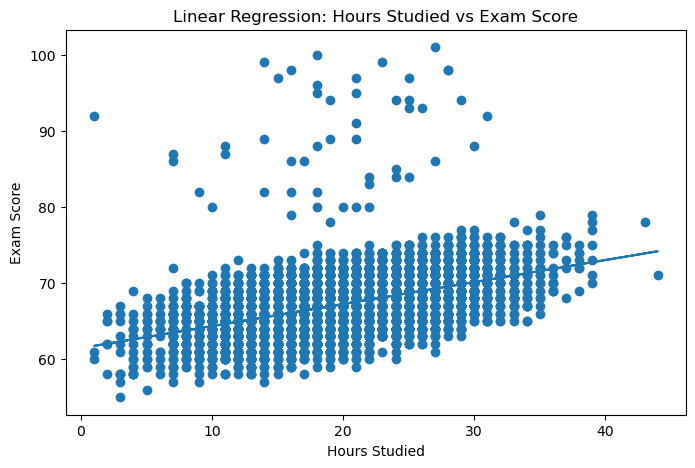

In [74]:
plt.figure(figsize=(8,5))

plt.scatter(df['Hours_Studied'], df['Exam_Score'])

plt.plot(
    df['Hours_Studied'],
    model.predict(X)
)

plt.xlabel('Hours Studied')
plt.ylabel('Exam Score')
plt.title('Linear Regression: Hours Studied vs Exam Score')

plt.show()

In [75]:
X = df[['Attendance']]
y = df['Exam_Score']

model2 = LinearRegression()

model2.fit(X, y)

print("Intercept:", model2.intercept_)
print("Slope:", model2.coef_[0])
print("R² Score:", model2.score(X, y))

Intercept: 51.57857651128339
Slope: 0.19576871978431692
R² Score: 0.33764451033295395


In [76]:
from sklearn.linear_model import LinearRegression

X = df[['Hours_Studied', 'Attendance', 'Previous_Scores']]
y = df['Exam_Score']

model3 = LinearRegression()
model3.fit(X, y)

print("Intercept:", model3.intercept_)
print("Coefficients:")
print("Hours Studied:", model3.coef_[0])
print("Attendance:", model3.coef_[1])
print("Previous Scores:", model3.coef_[2])

print("R² Score:", model3.score(X, y))

Intercept: 41.99897113525883
Coefficients:
Hours Studied: 0.290243147410067
Attendance: 0.19845661121297511
Previous Scores: 0.04751441347917033
R² Score: 0.5721542015340162


In [77]:
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model3.coef_
})

print(coef_df)

           Feature  Coefficient
0    Hours_Studied     0.290243
1       Attendance     0.198457
2  Previous_Scores     0.047514


In [78]:
X2 = df[['Hours_Studied',
         'Attendance',
         'Previous_Scores',
         'Tutoring_Sessions',
         'Physical_Activity']]

y = df['Exam_Score']

model4 = LinearRegression()

model4.fit(X2, y)

print("Intercept:", model4.intercept_)
print("R² Score:", model4.score(X2, y))

print("\nCoefficients:")
for feature, coef in zip(X2.columns, model4.coef_):
    print(feature, ":", coef)

Intercept: 40.7949355932998
R² Score: 0.5982034298759604

Coefficients:
Hours_Studied : 0.29152988463748863
Attendance : 0.19801443117389333
Previous_Scores : 0.048163939682591514
Tutoring_Sessions : 0.49376540063591634
Physical_Activity : 0.1440182594611204


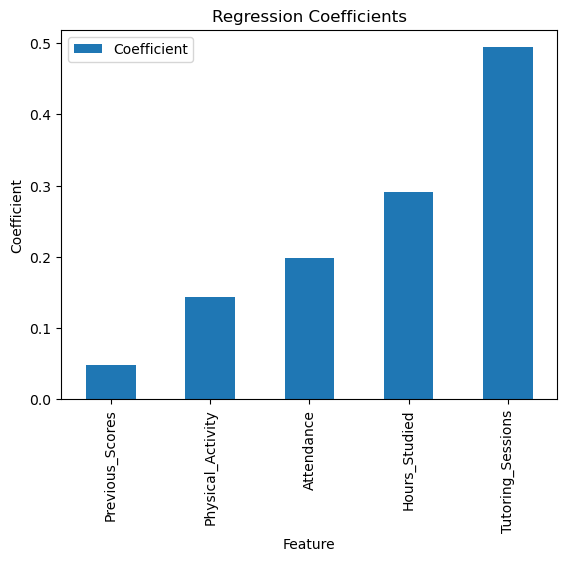

In [79]:
coef_df = pd.DataFrame({
    'Feature': X2.columns,
    'Coefficient': model4.coef_
})

coef_df.sort_values(by='Coefficient').plot(
    x='Feature',
    y='Coefficient',
    kind='bar'
)

plt.ylabel('Coefficient')
plt.title('Regression Coefficients')
plt.show()

In [80]:
comparison = pd.DataFrame({
    'Model': [
        'Hours Studied',
        'Attendance',
        'Hours+Attendance+Previous',
        '5-variable model'
    ],
    'R_squared': [
        0.198,
        0.338,
        0.572,
        0.598
    ]
})

print(comparison)

                       Model  R_squared
0              Hours Studied      0.198
1                 Attendance      0.338
2  Hours+Attendance+Previous      0.572
3           5-variable model      0.598


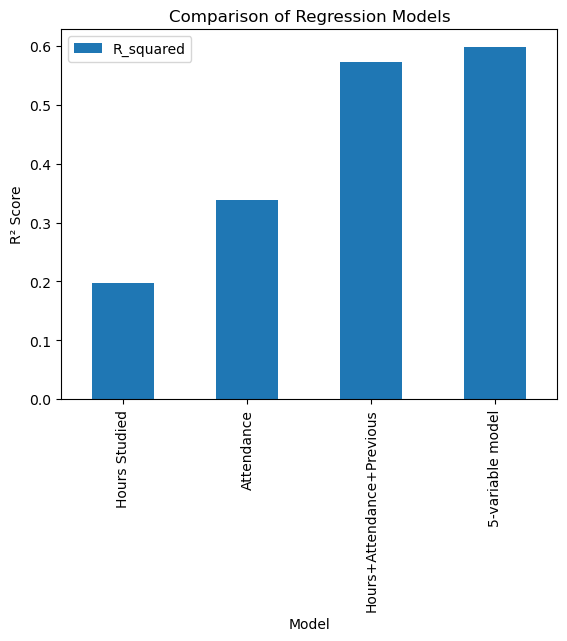

In [81]:
comparison.plot(
    x='Model',
    y='R_squared',
    kind='bar'
)

plt.ylabel('R² Score')
plt.title('Comparison of Regression Models')
plt.show()

In [82]:
predictions = model4.predict(X2)

comparison_df = pd.DataFrame({
    'Actual Score': y,
    'Predicted Score': predictions
})

print(comparison_df.head(10))

   Actual Score  Predicted Score
0            67        68.081358
1            61        63.412203
2            74        73.143589
3            71        72.662491
4            70        69.739356
5            71        69.959215
6            67        69.939464
7            66        66.718307
8            69        68.361434
9            72        71.045268


In [83]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(y, predictions)

rmse = np.sqrt(mean_squared_error(y, predictions))

print("Mean Absolute Error:", mae)
print("Root Mean Squared Error:", rmse)

Mean Absolute Error: 1.3123991688052252
Root Mean Squared Error: 2.4658731249680774


RMSE is larger because:

MAE treats all errors equally.
RMSE penalizes larger errors more heavily.

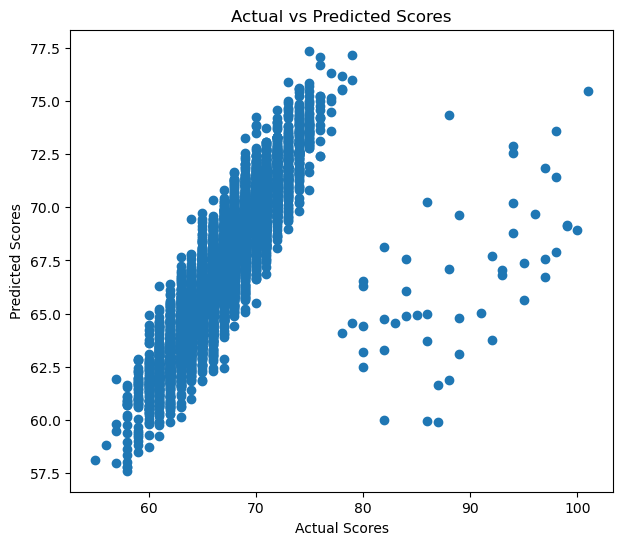

In [84]:
plt.figure(figsize=(7,6))

plt.scatter(y, predictions)

plt.xlabel('Actual Scores')
plt.ylabel('Predicted Scores')
plt.title('Actual vs Predicted Scores')

plt.show()

In [85]:
residuals = y - predictions

print(residuals.describe())

count    6.607000e+03
mean    -6.683855e-15
std      2.466060e+00
min     -5.457752e+00
25%     -1.132638e+00
50%     -1.612896e-01
75%      8.448102e-01
max      3.104894e+01
Name: Exam_Score, dtype: float64


In [86]:
comparison_df['Residual'] = residuals

comparison_df.sort_values(
    by='Residual',
    ascending=False
).head(10)

,Actual Score,Predicted Score,Residual
94,100,68.951058,31.048942
919,97,66.735325,30.264675
6393,98,67.889298,30.110702
3579,99,69.102850,29.897150
2425,99,69.147732,29.852268
529,97,67.550551,29.449449
4297,95,65.636313,29.363687
4779,92,63.748872,28.251128
6522,95,67.390445,27.609555
2595,87,59.881295,27.118705


In [88]:
findings = pd.DataFrame({
    'Analysis': [
        'Hours Studied Correlation',
        'Attendance Correlation',
        'Previous Scores Correlation',
        'Tutoring Sessions Correlation',
        'Physical Activity Correlation',
        'Multiple Regression R²'
    ],
    'Result': [
        0.445,
        0.581,
        0.181,
        0.157,
        0.028,
        0.598
    ]
})

print(findings)

                        Analysis  Result
0      Hours Studied Correlation   0.445
1         Attendance Correlation   0.581
2    Previous Scores Correlation   0.181
3  Tutoring Sessions Correlation   0.157
4  Physical Activity Correlation   0.028
5         Multiple Regression R²   0.598


In [89]:
hypothesis_results = pd.DataFrame({
    'Variable': [
        'Access_to_Resources',
        'Parental_Involvement',
        'Motivation_Level',
        'Hours_Studied'
    ],
    'Test': [
        'ANOVA',
        'ANOVA',
        'ANOVA',
        'Pearson Correlation'
    ],
    'Conclusion': [
        'Significant',
        'Significant',
        'Significant',
        'Significant'
    ]
})

print(hypothesis_results)

               Variable                 Test   Conclusion
0   Access_to_Resources                ANOVA  Significant
1  Parental_Involvement                ANOVA  Significant
2      Motivation_Level                ANOVA  Significant
3         Hours_Studied  Pearson Correlation  Significant


In [91]:
df['Exam_Score'].describe()

count    6607.000000
mean       67.235659
std         3.890456
min        55.000000
25%        65.000000
50%        67.000000
75%        69.000000
max       101.000000
Name: Exam_Score, dtype: float64

In [93]:
df['Hours_Studied'].describe()

count    6607.000000
mean       19.975329
std         5.990594
min         1.000000
25%        16.000000
50%        20.000000
75%        24.000000
max        44.000000
Name: Hours_Studied, dtype: float64

In [5]:
df['Attendance'].describe()

count    6607.000000
mean       79.977448
std        11.547475
min        60.000000
25%        70.000000
50%        80.000000
75%        90.000000
max       100.000000
Name: Attendance, dtype: float64

<Axes: >

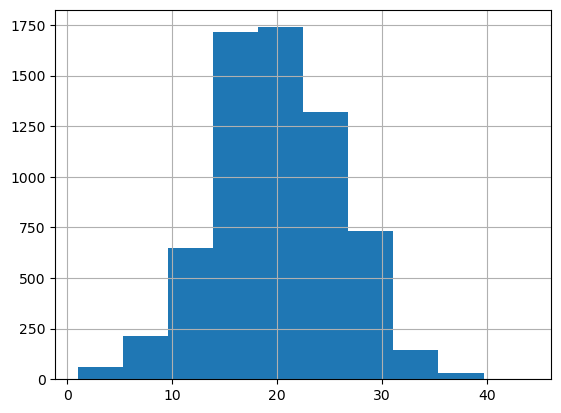

In [8]:
df['Hours_Studied'].hist()

<Axes: >

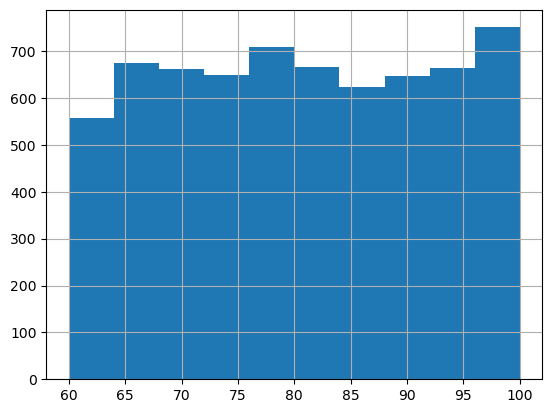

In [3]:
df['Attendance'].hist()

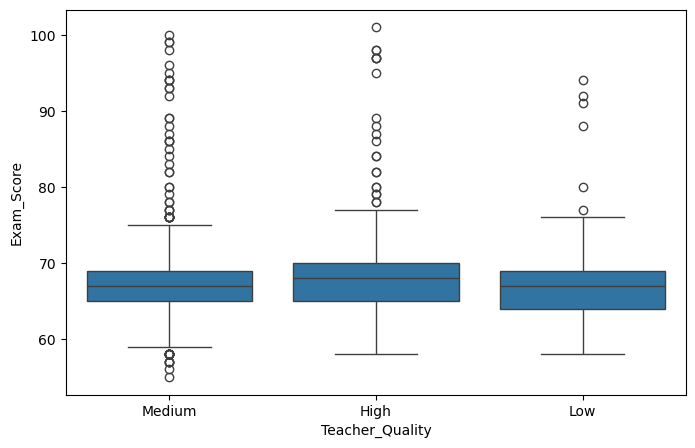

In [10]:
import seaborn as sns

plt.figure(figsize=(8,5))

sns.boxplot(
    x='Teacher_Quality',
    y='Exam_Score',
    data=df
)

plt.show()

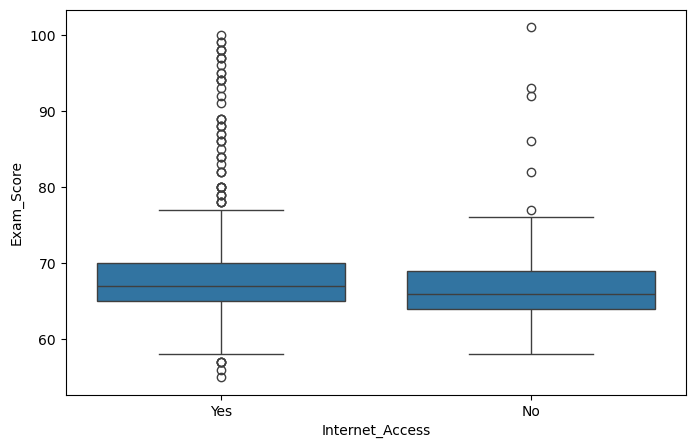

In [12]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Internet_Access',
    y='Exam_Score',
    data=df
)

plt.show()

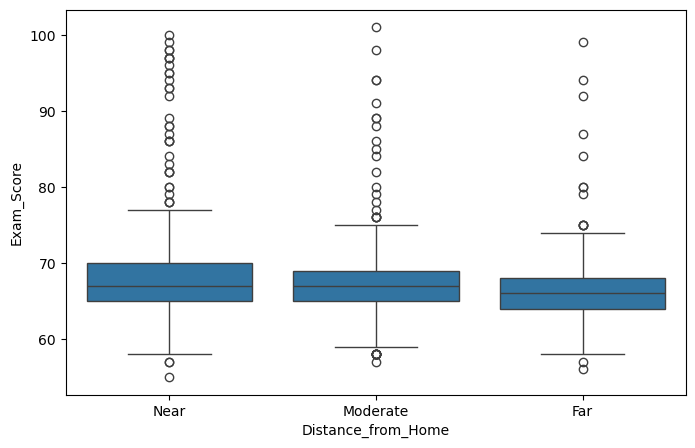

In [14]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Distance_from_Home',
    y='Exam_Score',
    data=df
)

plt.show()